# Tutorial 10: Plotting Functions

This tutorial provides a standalone demonstration of every plotting function in
`brutus.plotting`. The module contains seven public functions for visualizing
posterior distributions, SEDs, photometric offsets, and binned distance-reddening
PDFs.

## Functions Covered

| Function | Module | Description |
|---|---|---|
| `hist2d` | `brutus.plotting.utils` | 2-D density histogram with contours |
| `dist_vs_red` | `brutus.plotting.distance` | Distance vs reddening posterior plot |
| `cornerplot` | `brutus.plotting.corner` | Corner plot of multi-dimensional posteriors |
| `posterior_predictive` | `brutus.plotting.sed` | Posterior predictive SED violin plot |
| `photometric_offsets` | `brutus.plotting.offsets` | 1-D photometric offset residuals |
| `photometric_offsets_2d` | `brutus.plotting.offsets` | 2-D spatial photometric offsets |
| `bin_pdfs_distred` | `brutus.plotting.binning` | Bin distance-reddening posterior PDFs |

## Prerequisites

- Sections 1 (hist2d) use **synthetic data** and always run.
- Sections 2-4 and 7 use pre-computed BruteForce results from
  `Orion_l204.7_b-19.2_mist.h5` and optionally the input photometry
  `Orion_l204.7_b-19.2.h5`. If these are not available the cells print a
  skip message.
- Sections 5-6 require the model grid in memory and are documented
  (signature + description) without being executed.

In [1]:
# Setup: imports and plot style
import warnings

import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# Tutorial utilities
from tutorial_utils import (
    setup_tutorial,
    save_figure,
    print_section,
    find_brutus_data_file,
    load_example_results,
)

# Run the standardized tutorial bootstrap
info = setup_tutorial(10, title="Tutorial 10: Plotting Functions")

# Matplotlib defaults for this notebook
plt.rcParams["figure.figsize"] = (10, 6)


Tutorial 10: Plotting Functions

Checking data requirements for Tutorial 10
  Found: Orion_l204.7_b-19.2_mist.h5

  All required files available


In [2]:
# ---------------------------------------------------------------
# Load pre-computed BruteForce results, input photometry, and models
# ---------------------------------------------------------------
import h5py
from brutus.utils import inv_magnitude
from brutus.data import load_models

DATA_AVAILABLE = False
PHOT_AVAILABLE = False
MODELS_AVAILABLE = False

# Filter names used in the Orion fitting run (PS1 grizy + 2MASS JHKs)
FILTER_NAMES = ['PS_g', 'PS_r', 'PS_i', 'PS_z', 'PS_y',
                '2MASS_J', '2MASS_H', '2MASS_Ks']
N_OBJ_RESULTS = None

# 1. Load BruteForce results
try:
    results = load_example_results("Orion_l204.7_b-19.2_mist.h5")
    DATA_AVAILABLE = True
    N_OBJ_RESULTS = results["model_idx"].shape[0]
    n_samps = results["model_idx"].shape[1]
    print("Loaded BruteForce results.")
    print(f"  File      : {results['filename']}")
    print(f"  Objects   : {N_OBJ_RESULTS}")
    print(f"  Samples   : {n_samps}")
    for key in sorted(results):
        if key == "filename":
            continue
        arr = results[key]
        if isinstance(arr, np.ndarray):
            print(f"  {key:15s}  shape={str(arr.shape):20s}  dtype={arr.dtype}")
except FileNotFoundError as exc:
    print(f"Results file not found -- sections that need it will be skipped.")
    print(f"  ({exc})")

# 2. Load input photometry (subset to match results)
try:
    phot_path = find_brutus_data_file("Orion_l204.7_b-19.2.h5")
    with h5py.File(phot_path, "r") as f:
        fpix = f["photometry"]["pixel 0-0"]
        mag_all = fpix["mag"][:]
        magerr_all = fpix["err"][:]
        plx_all = fpix["parallax"][:] * 1e3   # arcsec -> mas
        plx_err_all = fpix["parallax_error"][:] * 1e3
        coords_all = np.c_[fpix["l"][:], fpix["b"][:]]

    # Convert to flux
    flux_all, flux_err_all = inv_magnitude(mag_all, magerr_all)
    mask_all = np.isfinite(magerr_all)

    # Subset to match results objects (first N)
    n_sub = N_OBJ_RESULTS if N_OBJ_RESULTS is not None else flux_all.shape[0]
    phot_flux = flux_all[:n_sub]
    phot_flux_err = flux_err_all[:n_sub]
    phot_mask = mask_all[:n_sub]
    phot_parallax = plx_all[:n_sub]
    phot_parallax_err = plx_err_all[:n_sub]
    phot_coords = coords_all[:n_sub]

    PHOT_AVAILABLE = True
    print(f"\nLoaded input photometry from {phot_path}")
    print(f"  Total objects  : {flux_all.shape[0]}")
    print(f"  Subset matched : {n_sub}")
    print(f"  Filters        : {flux_all.shape[1]}")
except FileNotFoundError as exc:
    print(f"\nInput photometry not found (optional).")
    print(f"  ({exc})")

# 3. Load model grid (needed for SED, cornerplot, and offset plots)
try:
    grid_path = find_brutus_data_file("grid_mist_v9.h5")
    models, grid_labels, label_mask = load_models(grid_path, filters=FILTER_NAMES)
    MODELS_AVAILABLE = True
    print(f"\nLoaded model grid from {grid_path}")
    print(f"  models shape  : {models.shape}  (Nmodels, Nfilt, Ncoeff)")
    print(f"  labels shape  : {grid_labels.shape}")
    print(f"  labels fields : {list(grid_labels.dtype.names)}")
except FileNotFoundError as exc:
    print(f"\nModel grid not found.")
    print(f"  ({exc})")

Loaded BruteForce results.
  File      : /mnt/c/Users/joshs/Dropbox/GitHub/brutus/tutorials/Orion_l204.7_b-19.2_mist.h5
  Objects   : 50
  Samples   : 250
  labels           shape=(50,)                 dtype=uint64
  ml_av            shape=(50, 250)             dtype=float32
  ml_cov_sar       shape=(50, 250, 3, 3)       dtype=float32
  ml_rv            shape=(50, 250)             dtype=float32
  ml_scale         shape=(50, 250)             dtype=float32
  model_idx        shape=(50, 250)             dtype=int32
  obj_Nbands       shape=(50,)                 dtype=int16
  obj_chi2min      shape=(50,)                 dtype=float32
  obj_log_evid     shape=(50,)                 dtype=float32
  obj_log_post     shape=(50, 250)             dtype=float32
  samps_dist       shape=(50, 250)             dtype=float32
  samps_dred       shape=(50, 250)             dtype=float32
  samps_logp       shape=(50, 250)             dtype=float32
  samps_red        shape=(50, 250)             dtype=floa

Reading entire dataset (49 filters) once...


Extracting 8 requested filters from memory...



Loaded model grid from /mnt/c/Users/joshs/Dropbox/GitHub/brutus/data/DATAFILES/grid_mist_v9.h5
  models shape  : (613530, 8, 3)  (Nmodels, Nfilt, Ncoeff)
  labels shape  : (613530,)
  labels fields : ['mini', 'feh', 'eep', 'loga', 'logl', 'logt', 'logg', 'agewt']


---
## Section 1: `hist2d` -- 2-D Density Histogram

`hist2d` draws a smoothed 2-D density map with optional contour levels.
It is the low-level workhorse used internally by `cornerplot` for each
off-diagonal panel, but it is also useful as a standalone visualization
for any pair of posterior samples.

### Signature

```python
hist2d(x, y, smooth=0.02, span=None, weights=None, levels=None, ax=None,
       color='gray', plot_datapoints=False, plot_density=True,
       plot_contours=True, no_fill_contours=False, fill_contours=True,
       contour_kwargs=None, contourf_kwargs=None, data_kwargs=None)
```

Below we demonstrate `hist2d` on **real BruteForce posterior samples**
from the Orion sightline, plotting distance vs reddening for three objects.


Section 1: hist2d


  Saved: /mnt/c/Users/joshs/Dropbox/GitHub/brutus/tutorials/plots/tutorial_10/hist2d_demo.png


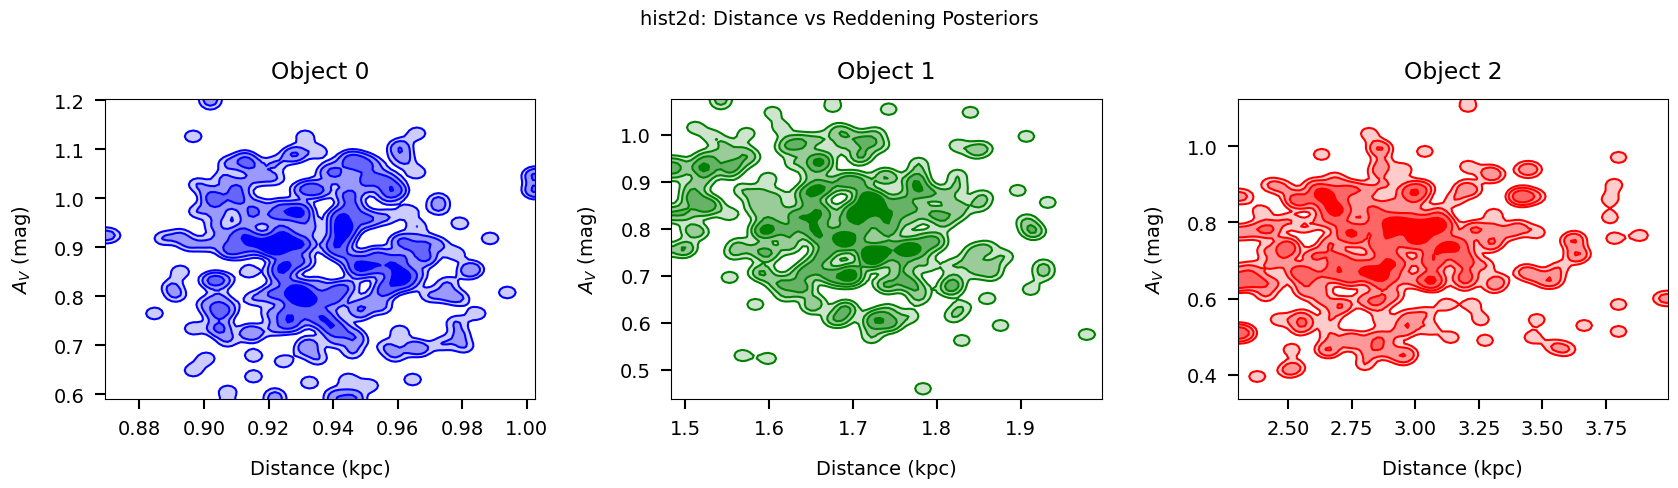

hist2d renders smoothed 2-D density maps with contours.
It can show filled contours, unfilled contours, density colormaps,
and/or raw data points via its boolean flags.


In [3]:
from brutus.plotting import hist2d

print_section("Section 1: hist2d")

if not DATA_AVAILABLE:
    print("SKIPPED -- results file not available.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(17, 5))
    colors = ["blue", "green", "red"]
    obj_indices = [0, 1, 2]

    for ax, idx, color in zip(axes, obj_indices, colors):
        dist_samps = results["samps_dist"][idx]
        av_samps = results["samps_red"][idx]

        # Filled contours (default)
        hist2d(dist_samps, av_samps, smooth=0.02, color=color, ax=ax,
               fill_contours=True, plot_datapoints=True,
               data_kwargs={"alpha": 0.15, "ms": 2})
        ax.set_xlabel("Distance (kpc)")
        ax.set_ylabel(r"$A_V$ (mag)")
        ax.set_title(f"Object {idx}")

    plt.suptitle("hist2d: Distance vs Reddening Posteriors", fontsize=14)
    save_figure(fig, 10, "hist2d_demo")
    plt.show()

    print("hist2d renders smoothed 2-D density maps with contours.")
    print("It can show filled contours, unfilled contours, density colormaps,")
    print("and/or raw data points via its boolean flags.")

---
## Section 2: `dist_vs_red` -- Distance vs Reddening Plot

`dist_vs_red` creates a 2-D density image of the joint distance-reddening
posterior for one or more objects. Internally it calls `bin_pdfs_distred` to
handle all coordinate transforms and smoothing.

### Signature

```python
dist_vs_red(data, ebv=None, dist_type='distance_modulus', lndistprior=None,
            coord=None, avlim=(0., 6.), rvlim=(1., 8.), weights=None,
            parallax=None, parallax_err=None, Nr=300, cmap='Blues',
            bins=300, span=None, smooth=0.015, plot_kwargs=None,
            truths=None, truth_color='red', truth_kwargs=None, rstate=None)
```

`data` is a 4-tuple `(scales, avs, rvs, covs_sar)` -- the raw per-model
BruteForce outputs -- or a 3-tuple `(dists, reds, dreds)` of pre-drawn
samples. The function also needs Galactic coordinates (`coord`) and
parallax information when regenerating distance samples from the 4-tuple
format.


Section 2: dist_vs_red


  Saved: /mnt/c/Users/joshs/Dropbox/GitHub/brutus/tutorials/plots/tutorial_10/dist_vs_red_demo.png


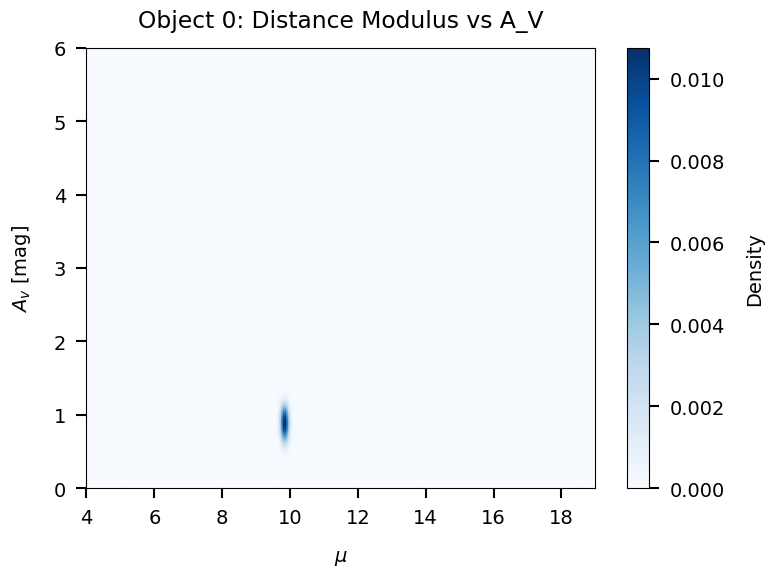


Plotted object 0.
  Binned histogram shape : (300, 300)
  Distance modulus range : [4.0, 19.0]
  A_V range              : [0.0, 6.0]


In [4]:
from brutus.plotting import dist_vs_red

print_section("Section 2: dist_vs_red")

if not DATA_AVAILABLE:
    print("SKIPPED -- results file not available.")
else:
    # Pick the first object as an example
    idx = 0

    # Build the 4-tuple that dist_vs_red expects (scale, Av, Rv, cov_sar)
    data_tuple = (
        results["ml_scale"][idx],
        results["ml_av"][idx],
        results["ml_rv"][idx],
        results["ml_cov_sar"][idx],
    )

    # Galactic coordinates for the distance prior
    coord = tuple(phot_coords[idx]) if PHOT_AVAILABLE else (204.7, -19.2)

    # Parallax
    plx = phot_parallax[idx] if PHOT_AVAILABLE else None
    plx_err = phot_parallax_err[idx] if PHOT_AVAILABLE else None

    fig = plt.figure(figsize=(8, 6))
    H, xedges, yedges, img = dist_vs_red(
        data_tuple,
        coord=coord,
        parallax=plx,
        parallax_err=plx_err,
        dist_type="distance_modulus",
        cmap="Blues",
        smooth=0.015,
        bins=300,
    )
    plt.title(f"Object {idx}: Distance Modulus vs A_V")
    plt.colorbar(img, label="Density")

    save_figure(fig, 10, "dist_vs_red_demo")
    plt.show()

    print(f"\nPlotted object {idx}.")
    print(f"  Binned histogram shape : {H.shape}")
    print(f"  Distance modulus range : [{xedges[0]:.1f}, {xedges[-1]:.1f}]")
    print(f"  A_V range              : [{yedges[0]:.1f}, {yedges[-1]:.1f}]")

---
## Section 3: `cornerplot` -- Corner Plot of Posteriors

`cornerplot` generates a corner plot showing 1-D and 2-D marginalized
posteriors for all stellar parameters (from the model grid labels) plus
A_V, R_V, parallax, and distance.

### Signature

```python
cornerplot(idxs, data, params,
           lndistprior=None, coord=None, avlim=(0., 6.), rvlim=(1., 8.),
           weights=None, parallax=None, parallax_err=None, Nr=500,
           applied_parallax=True, pcolor='blue', parallax_kwargs=None,
           span=None, quantiles=[0.025, 0.5, 0.975], color='black',
           smooth=10, hist_kwargs=None, hist2d_kwargs=None, labels=None,
           label_kwargs=None, show_titles=False, title_fmt='.2f',
           title_kwargs=None, title_quantiles=[0.025, 0.5, 0.975],
           truths=None, truth_color='red', truth_kwargs=None,
           max_n_ticks=5, top_ticks=False, use_math_text=False,
           verbose=False, fig=None, rstate=None)
```

Required inputs:
- `idxs` -- resampled model indices (shape `(Nsamps,)`).
- `data` -- 4-tuple `(scales, avs, rvs, covs_sar)` or 3-tuple `(dists, reds, dreds)`.
- `params` -- structured array of model parameters (from the grid via `load_models`).


Section 3: cornerplot


Quantiles:
mini [(0.025, np.float64(0.8750000000000003)), (0.5, np.float64(1.0500000000000005)), (0.975, np.float64(1.2750000000000008))]
Quantiles:
feh [(0.025, np.float64(-0.7124999999999988)), (0.5, np.float64(-0.09999999999999831)), (0.975, np.float64(0.30000000000000204))]
Quantiles:
eep [(0.025, np.float64(370.0)), (0.5, np.float64(442.0)), (0.975, np.float64(456.0))]
Quantiles:
loga [(0.025, np.float64(9.465241338009797)), (0.5, np.float64(9.849791395117133)), (0.975, np.float64(10.051082153372834))]
Quantiles:
logl [(0.025, np.float64(0.329651589183751)), (0.5, np.float64(0.4285395918453292)), (0.975, np.float64(0.5248467949096491))]
Quantiles:
logt [(0.025, np.float64(3.749565228908653)), (0.5, np.float64(3.776680532855328)), (0.975, np.float64(3.8054007333187183))]
Quantiles:
logg [(0.025, np.float64(3.9980454611166354)), (0.5, np.float64(4.098561191383948)), (0.975, np.float64(4.221587716143503))]
Quantiles:
Av [(0.025, np.float64(0.6258793078526093)), (0.5, np.float64(0.879

  Saved: /mnt/c/Users/joshs/Dropbox/GitHub/brutus/tutorials/plots/tutorial_10/cornerplot_demo.png


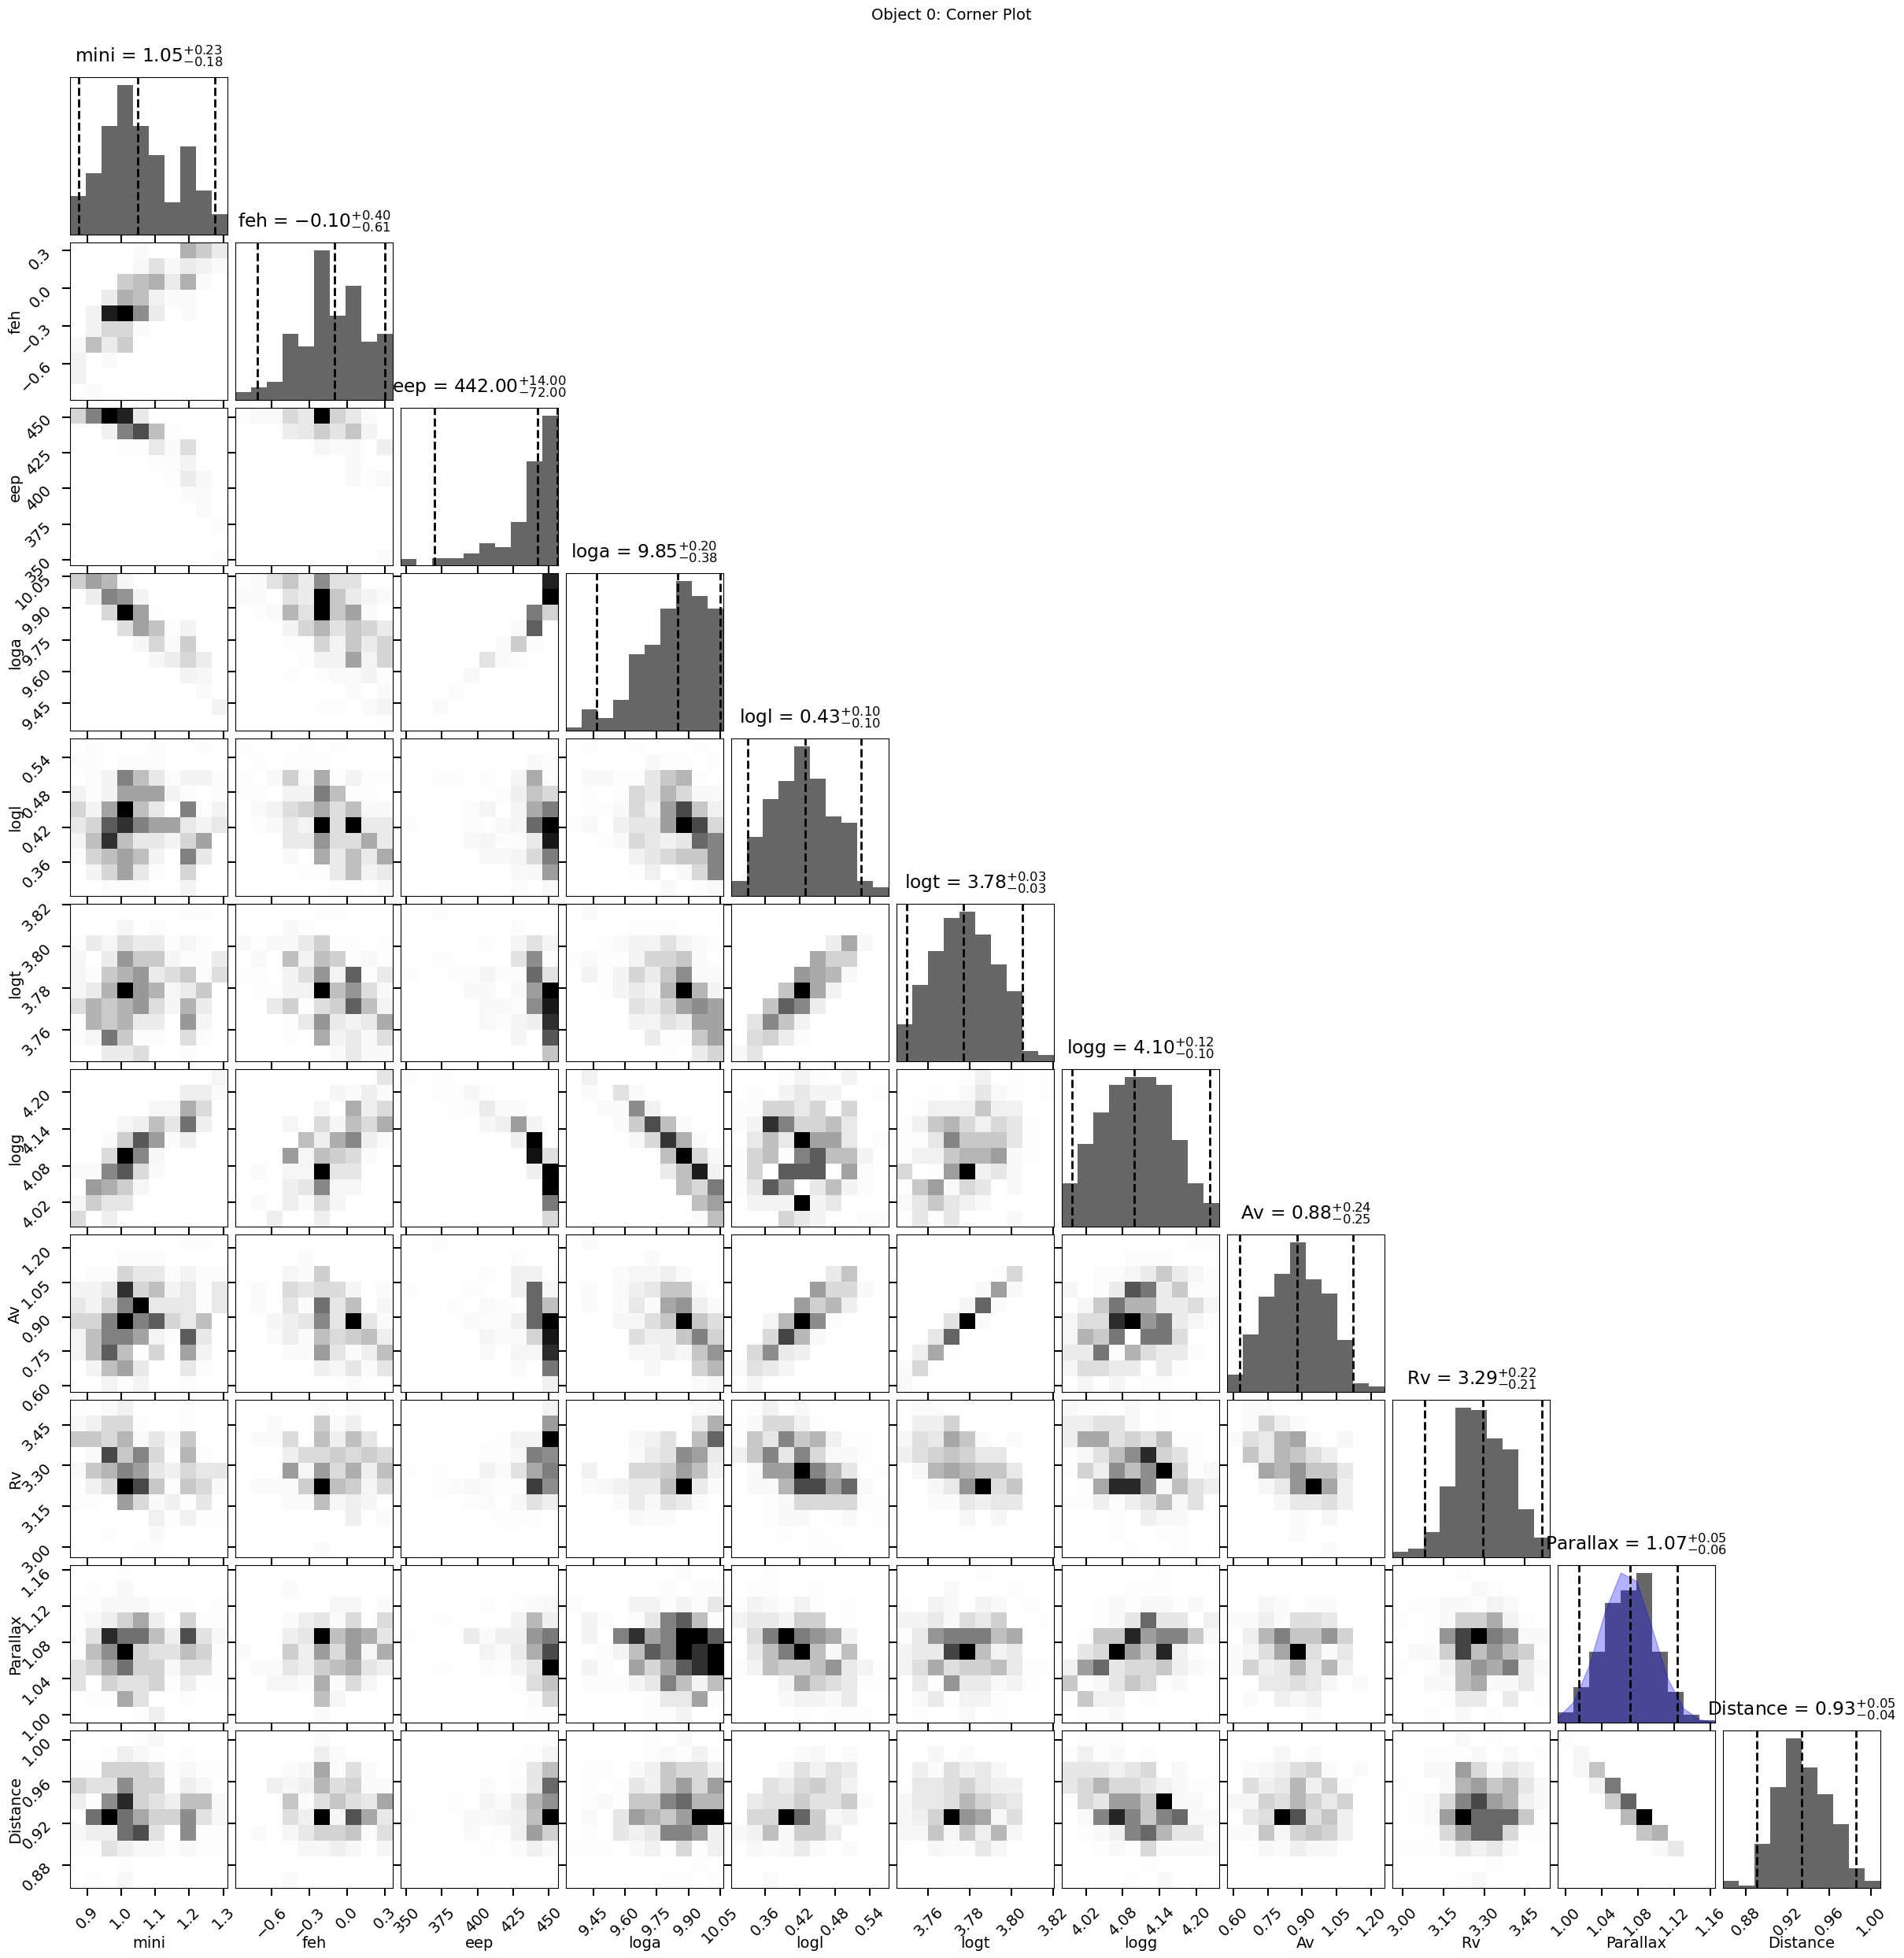


Corner plot has 11 rows/columns of panels.


In [5]:
from brutus.plotting import cornerplot

print_section("Section 3: cornerplot")

if DATA_AVAILABLE and MODELS_AVAILABLE:
    idx = 0

    idxs_obj = results["model_idx"][idx]
    data_tuple = (
        results["ml_scale"][idx],
        results["ml_av"][idx],
        results["ml_rv"][idx],
        results["ml_cov_sar"][idx],
    )

    coord = tuple(phot_coords[idx]) if PHOT_AVAILABLE else (204.7, -19.2)
    plx = phot_parallax[idx] if PHOT_AVAILABLE else None
    plx_err = phot_parallax_err[idx] if PHOT_AVAILABLE else None

    fig, axes = cornerplot(
        idxs_obj,
        data_tuple,
        grid_labels,
        coord=coord,
        parallax=plx,
        parallax_err=plx_err,
        applied_parallax=(plx is not None),
        smooth=10,
        show_titles=True,
        verbose=True,
    )
    fig.suptitle(f"Object {idx}: Corner Plot", y=1.02, fontsize=14)

    save_figure(fig, 10, "cornerplot_demo", tight=False)
    plt.show()

    print(f"\nCorner plot has {len(axes)} rows/columns of panels.")
else:
    print("SKIPPED -- need both results file and model grid.")

---
## Section 4: `posterior_predictive` -- SED Posterior Predictive Plot

`posterior_predictive` shows the predicted SED (as violin plots across
filters) compared with observed photometry. It uses the model
polynomial coefficients array (`models`) and pre-computed posterior
samples (`model_idx`, `samps_red`, `samps_dred`, `samps_dist`) from
BruteForce output.

### Signature

```python
posterior_predictive(models, idxs, reds, dreds, dists,
                     weights=None, flux=False,
                     data=None, data_err=None, data_mask=None,
                     offset=None, vcolor='black', pcolor='black',
                     labels=None, rstate=None, psig=2., fig=None)
```


Section 4: posterior_predictive


  Saved: /mnt/c/Users/joshs/Dropbox/GitHub/brutus/tutorials/plots/tutorial_10/posterior_predictive_demo.png


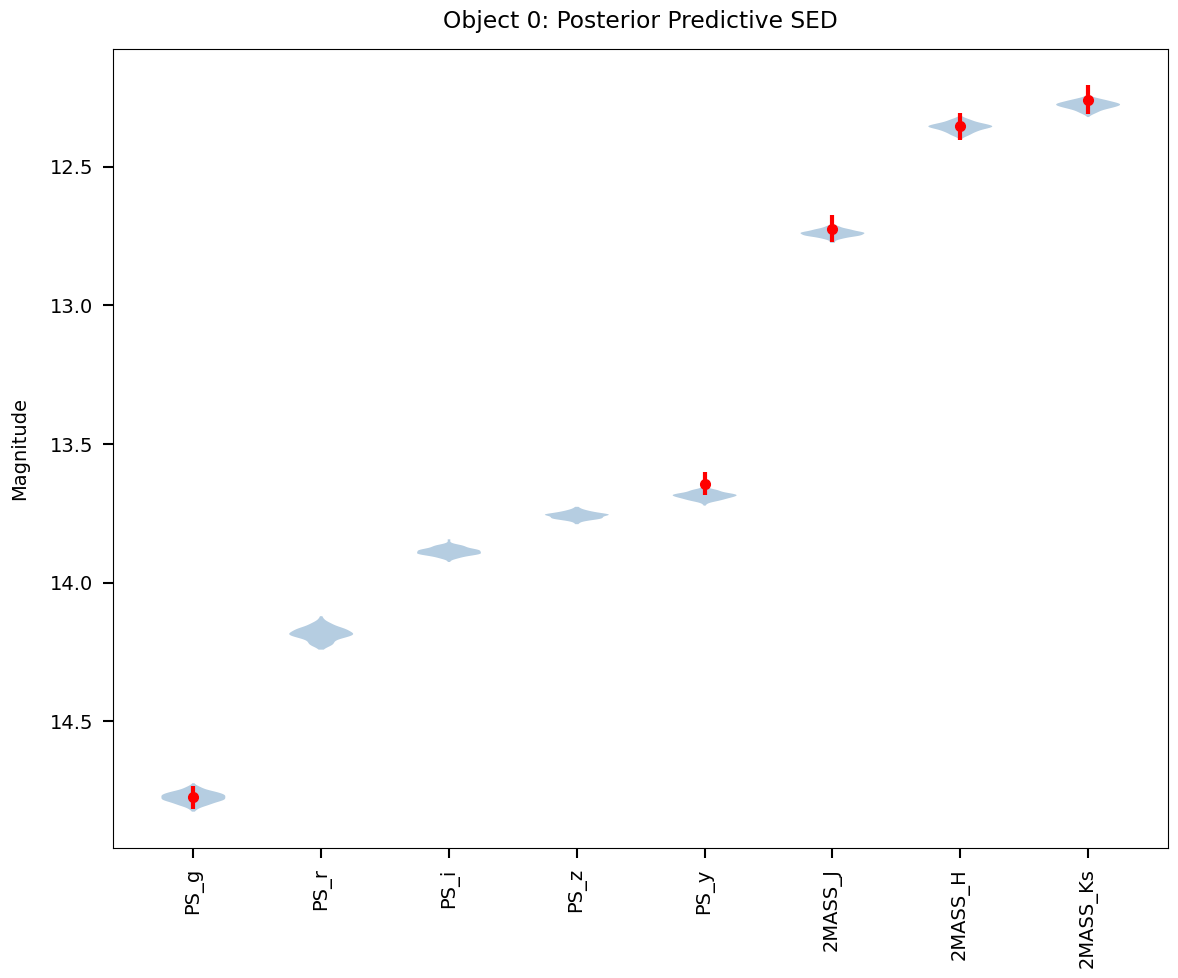


Violin bodies plotted across 8 filters.


In [6]:
from brutus.plotting import posterior_predictive

print_section("Section 4: posterior_predictive")

if DATA_AVAILABLE and MODELS_AVAILABLE:
    idx = 0

    # Use pre-computed posterior samples directly from BruteForce output
    idxs_obj = results["model_idx"][idx]
    reds_obj = results["samps_red"][idx]      # A_V samples
    dreds_obj = results["samps_dred"][idx]    # R_V samples
    dists_obj = results["samps_dist"][idx]    # distance in kpc

    # Observed photometry for overplot
    obs_flux = phot_flux[idx] if PHOT_AVAILABLE else None
    obs_err = phot_flux_err[idx] if PHOT_AVAILABLE else None
    obs_mask = phot_mask[idx] if PHOT_AVAILABLE else None

    fig, ax, parts = posterior_predictive(
        models,
        idxs_obj,
        reds_obj,
        dreds_obj,
        dists_obj,
        data=obs_flux,
        data_err=obs_err,
        data_mask=obs_mask,
        labels=FILTER_NAMES,
        vcolor="steelblue",
        pcolor="red",
    )
    ax.set_title(f"Object {idx}: Posterior Predictive SED")

    save_figure(fig, 10, "posterior_predictive_demo")
    plt.show()

    print(f"\nViolin bodies plotted across {len(FILTER_NAMES)} filters.")
else:
    print("SKIPPED -- need both results file and model grid.")

---
## Section 5: `photometric_offsets` -- 1-D Offset Residuals

`photometric_offsets` computes `mag_pred - mag_obs` for every band and
plots the residual as a function of observed magnitude. Each panel
corresponds to one photometric filter. This is a diagnostic tool for
identifying systematic model-data discrepancies as a function of brightness.

Note: this is a **plotting** function (`brutus.plotting.offsets`), distinct
from the **analysis** function of the same name (`brutus.analysis.offsets`)
demonstrated in Tutorial 8. The analysis function computes multiplicative
calibration corrections; this function visualizes magnitude residuals.

### Signature

```python
photometric_offsets(
    phot, err, mask, models, idxs, reds, dreds, dists,
    x=None, flux=True, weights=None, bins=100,
    offset=None, dim_prior=True, plot_thresh=0.,
    cmap='viridis', xspan=None, yspan=None,
    titles=None, xlabel=None, plot_kwargs=None, fig=None,
)
```


Section 5: photometric_offsets


  Saved: /mnt/c/Users/joshs/Dropbox/GitHub/brutus/tutorials/plots/tutorial_10/photometric_offsets_demo.png


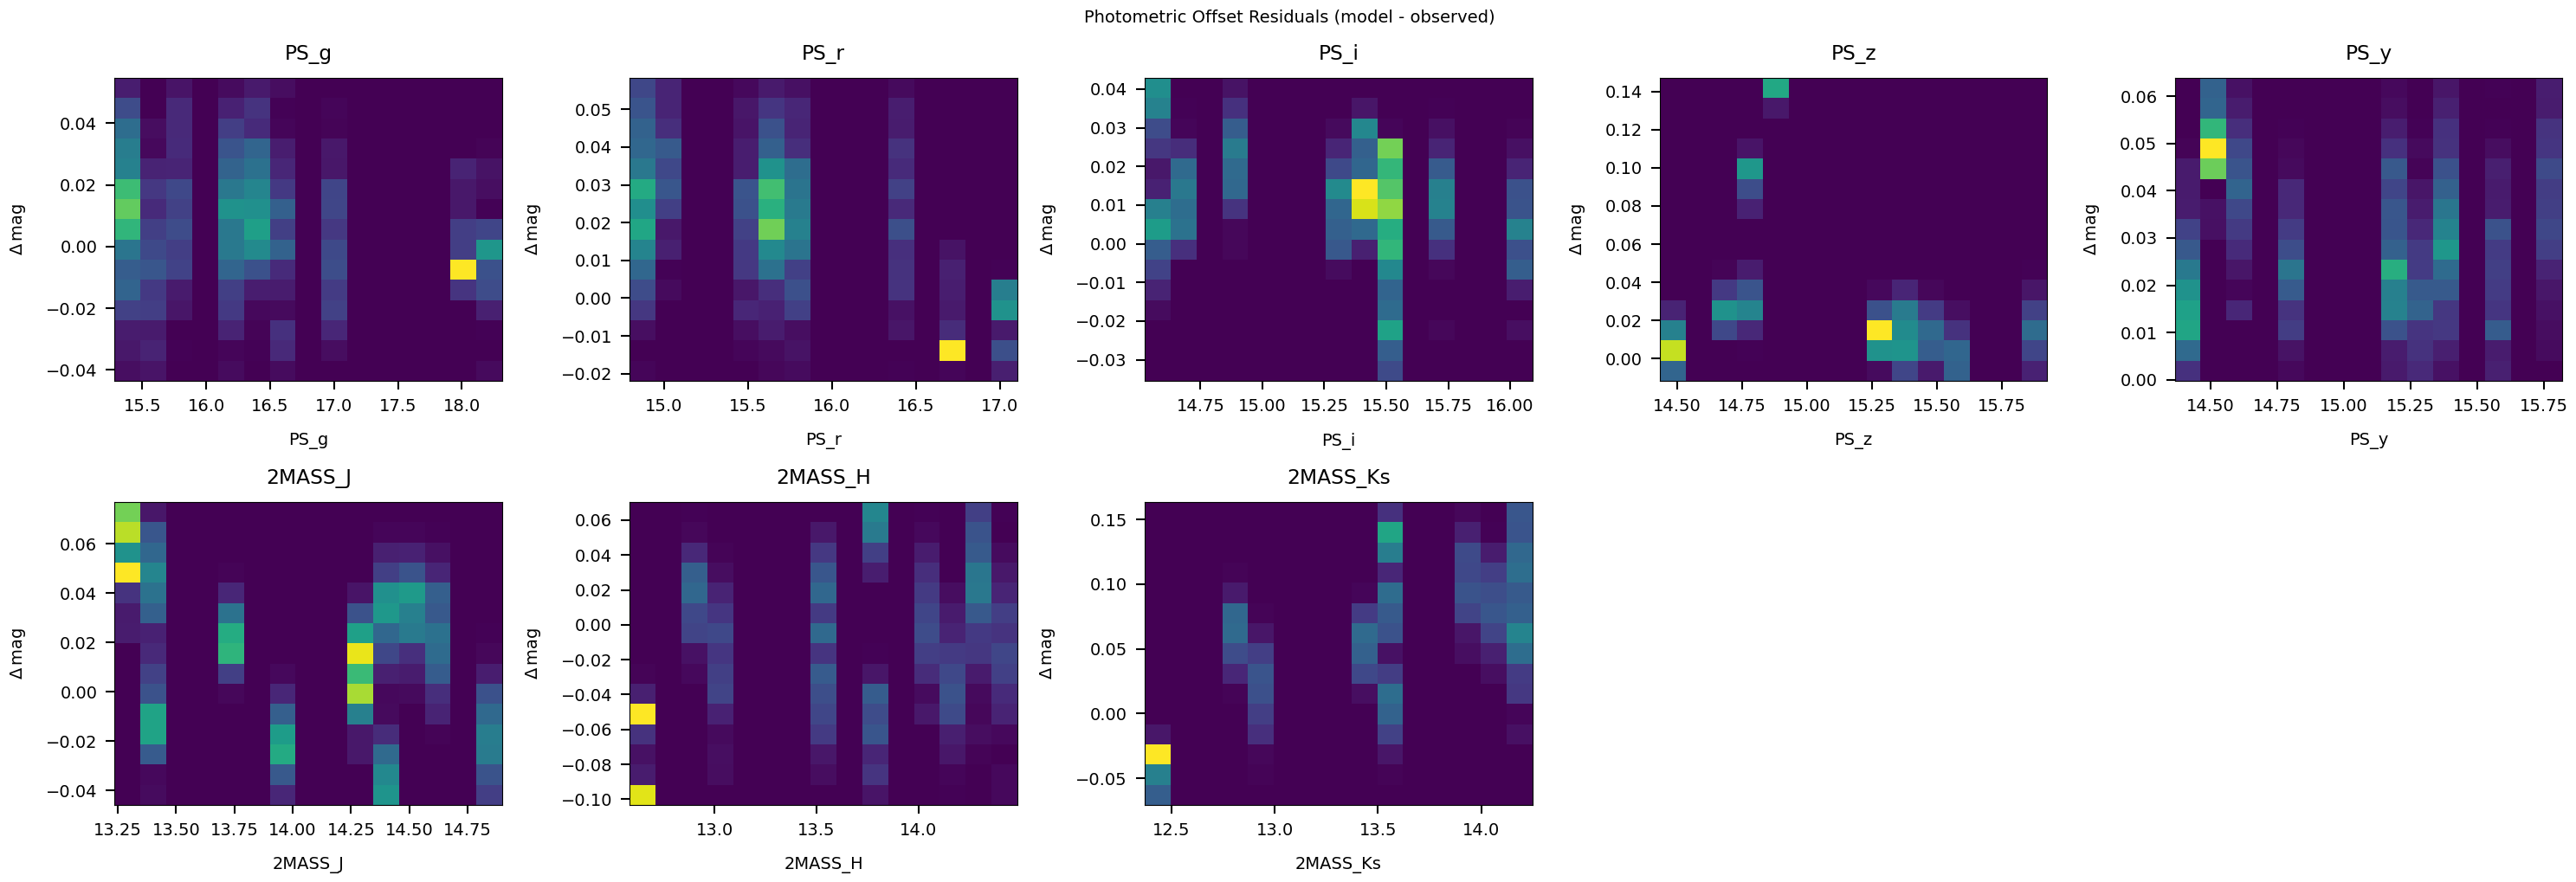


Plotted residuals for 8 filters across 50 objects.


In [7]:
from brutus.plotting import photometric_offsets as plot_phot_offsets

print_section("Section 5: photometric_offsets")

if DATA_AVAILABLE and MODELS_AVAILABLE and PHOT_AVAILABLE:
    # Use all 50 fitted objects with their posterior samples
    fig, axes = plot_phot_offsets(
        phot_flux,
        phot_flux_err,
        phot_mask,
        models,
        results["model_idx"],
        results["samps_red"],
        results["samps_dred"],
        results["samps_dist"],
        flux=True,
        bins=15,
        titles=FILTER_NAMES,
        cmap="viridis",
    )
    fig.suptitle(
        "Photometric Offset Residuals (model - observed)",
        fontsize=14, y=1.02,
    )

    save_figure(fig, 10, "photometric_offsets_demo", tight=False)
    plt.show()

    print(f"\nPlotted residuals for {len(FILTER_NAMES)} filters "
          f"across {phot_flux.shape[0]} objects.")
else:
    print("SKIPPED -- need results, photometry, and model grid.")

---
## Section 6: `photometric_offsets_2d` -- Spatial Offset Map

`photometric_offsets_2d` extends the 1-D offset analysis to show how
magnitude residuals vary **spatially** across a field. Each panel shows
a 2-D map of median `mag_pred - mag_obs` in bins of `(x, y)` coordinates.

### Signature

```python
photometric_offsets_2d(
    phot, err, mask, models, idxs, reds, dreds, dists,
    x, y,
    flux=True, weights=None, bins=100,
    offset=None, dim_prior=True, plot_thresh=10.,
    cmap='coolwarm', clims=(-0.05, 0.05),
    xspan=None, yspan=None, titles=None, show_off=True,
    xlabel=None, ylabel=None, plot_kwargs=None, fig=None,
)
```


Section 6: photometric_offsets_2d


  Saved: /mnt/c/Users/joshs/Dropbox/GitHub/brutus/tutorials/plots/tutorial_10/photometric_offsets_2d_demo.png


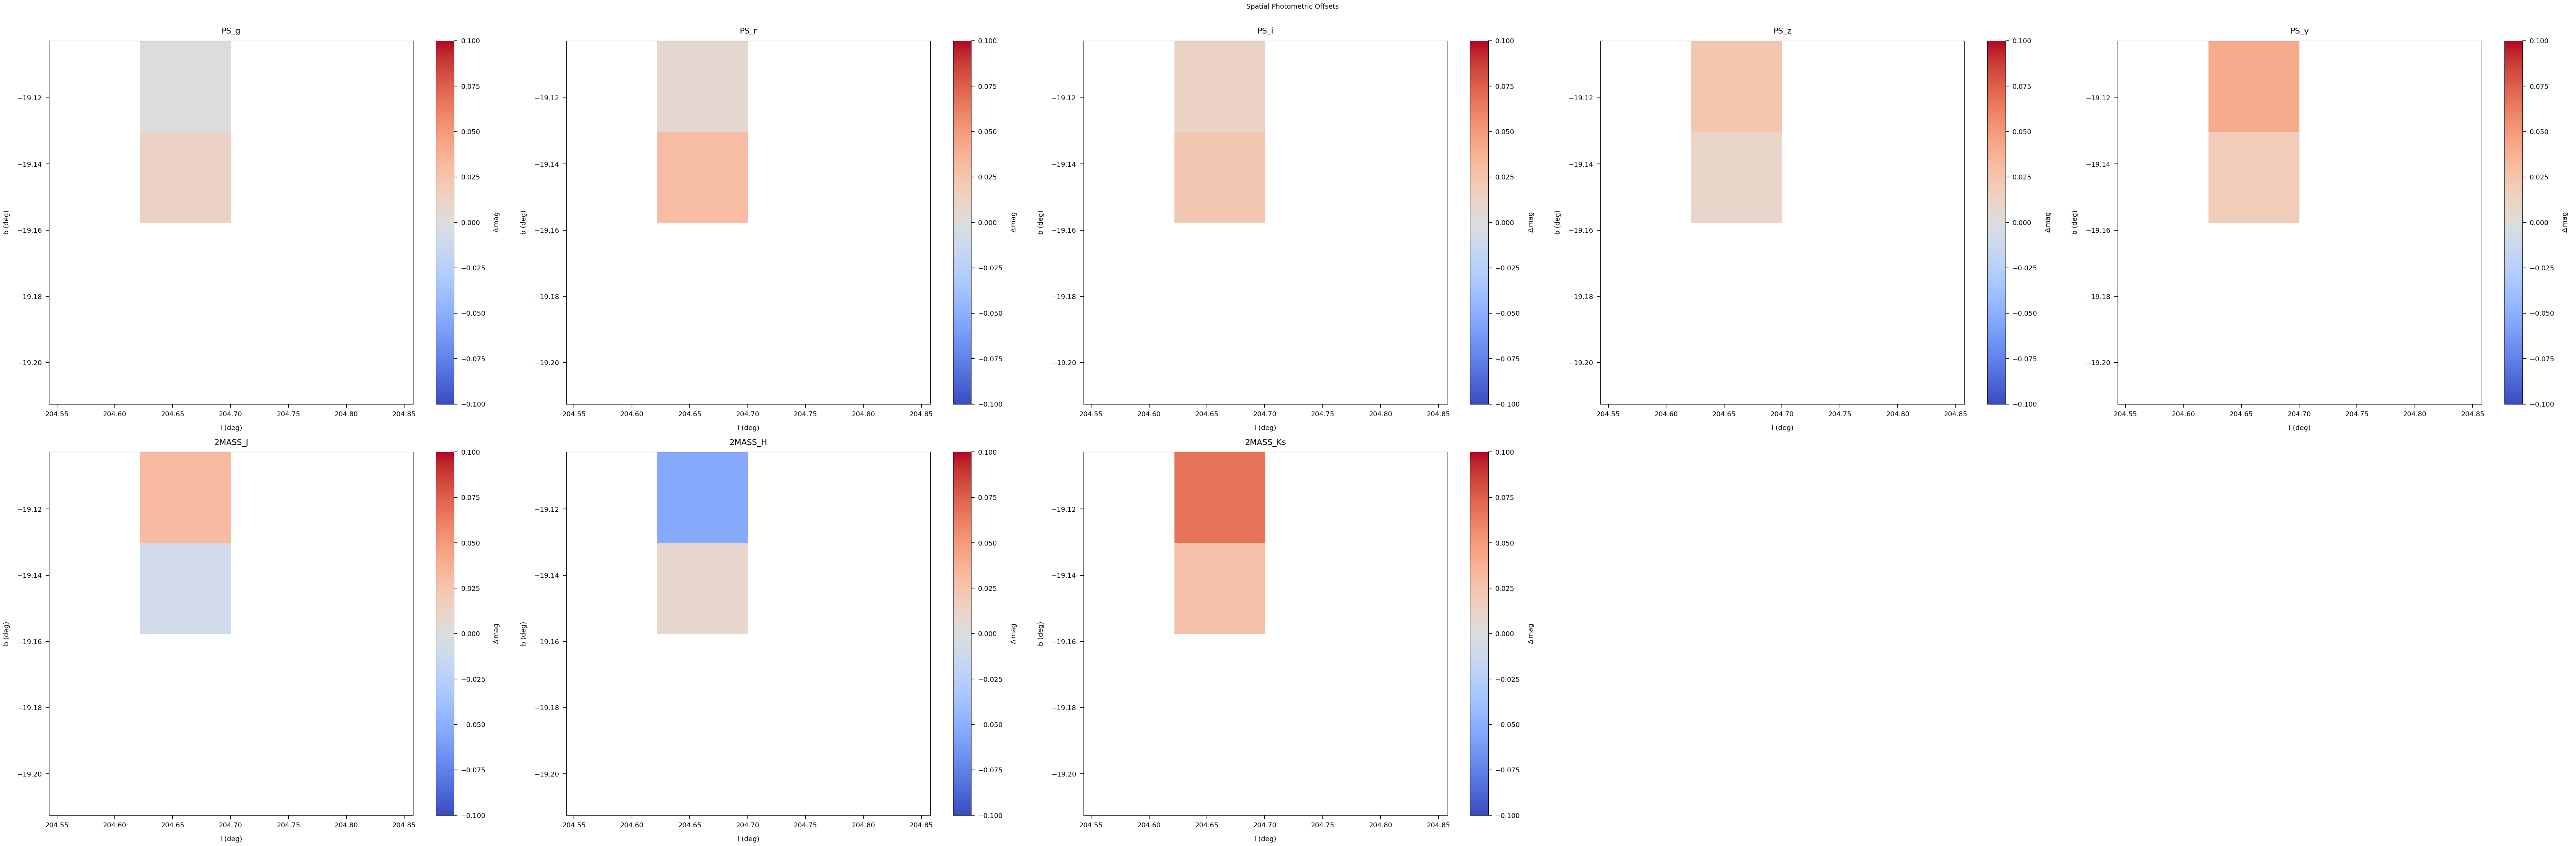


Plotted spatial offsets in (l, b) for 8 filters.
With only 50 objects the spatial resolution is coarse; larger
datasets reveal finer calibration patterns across the field.


In [8]:
from brutus.plotting import photometric_offsets_2d as plot_phot_offsets_2d

print_section("Section 6: photometric_offsets_2d")

if DATA_AVAILABLE and MODELS_AVAILABLE and PHOT_AVAILABLE:
    # Spatial offset map using Galactic coordinates.
    # With 50 objects we use coarse bins (4x4) so each bin has
    # enough objects for a meaningful median.
    fig, axes = plot_phot_offsets_2d(
        phot_flux,
        phot_flux_err,
        phot_mask,
        models,
        results["model_idx"],
        results["samps_red"],
        results["samps_dred"],
        results["samps_dist"],
        x=phot_coords[:, 0],   # Galactic longitude
        y=phot_coords[:, 1],   # Galactic latitude
        flux=True,
        bins=4,
        plot_thresh=2.,
        titles=FILTER_NAMES,
        xlabel="l (deg)",
        ylabel="b (deg)",
        cmap="coolwarm",
        clims=(-0.1, 0.1),
    )
    fig.suptitle("Spatial Photometric Offsets", fontsize=14, y=1.02)

    save_figure(fig, 10, "photometric_offsets_2d_demo", tight=False)
    plt.show()

    print(f"\nPlotted spatial offsets in (l, b) for {len(FILTER_NAMES)} filters.")
    print("With only 50 objects the spatial resolution is coarse; larger")
    print("datasets reveal finer calibration patterns across the field.")
else:
    print("SKIPPED -- need results, photometry, and model grid.")

---
## Section 7: `bin_pdfs_distred` -- Bin Distance-Reddening PDFs

`bin_pdfs_distred` is the data-preparation workhorse behind `dist_vs_red`.
It takes raw BruteForce outputs for *multiple* objects and returns a 3-D
array of binned 2-D PDFs (or CDFs) over the distance-reddening plane.

### Signature

```python
bin_pdfs_distred(
    data,           # 4-tuple (scales, avs, rvs, covs_sar) or 3-tuple
    cdf=False, ebv=False, dist_type='distance_modulus',
    lndistprior=None, coord=None, avlim=(0., 6.), rvlim=(1., 8.),
    parallaxes=None, parallax_errors=None, Nr=100,
    bins=(750, 300), span=None, smooth=0.01, rstate=None, verbose=False,
)
```

### Returns

- `binned_vals` -- `(Nobj, Nxbin, Nybin)` array of binned PDF values.
- `xedges` -- `(Nxbin+1,)` bin edges in the distance dimension.
- `yedges` -- `(Nybin+1,)` bin edges in the reddening dimension.


Section 7: bin_pdfs_distred


binned_vals shape : (5, 200, 100)  (Nobj, Nxbin, Nybin)
xedges shape      : (201,)
yedges shape      : (101,)


Binning object 5/5

  Saved: /mnt/c/Users/joshs/Dropbox/GitHub/brutus/tutorials/plots/tutorial_10/bin_pdfs_distred_demo.png


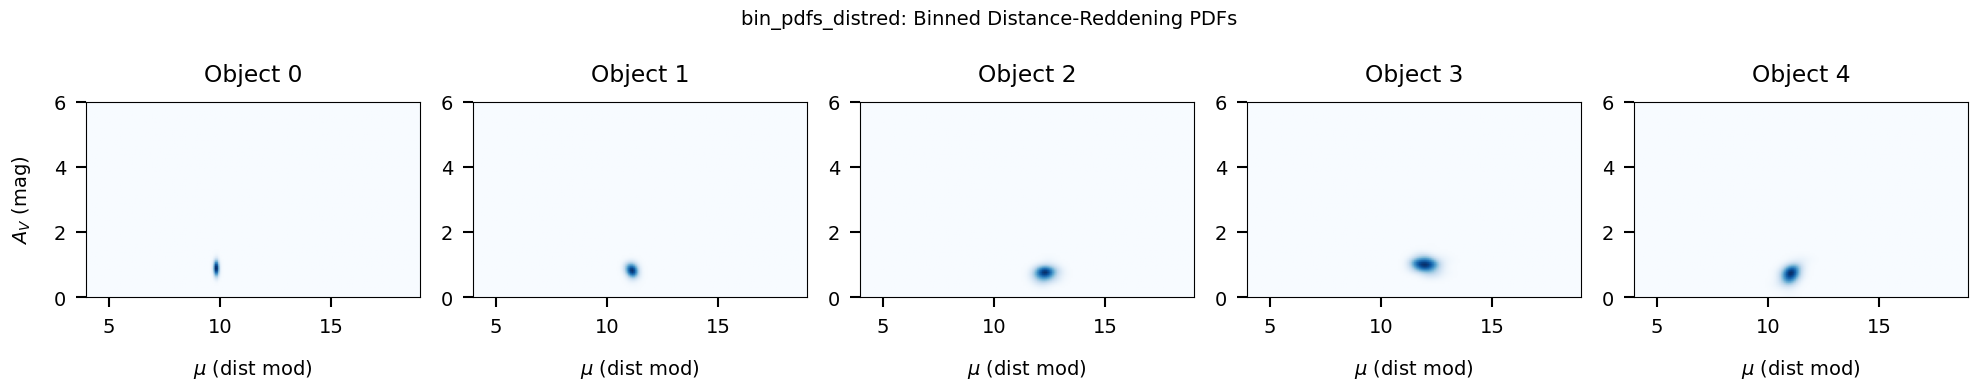


Plotted 5 objects.


In [9]:
from brutus.plotting import bin_pdfs_distred

print_section("Section 7: bin_pdfs_distred")

if not DATA_AVAILABLE:
    print("SKIPPED -- results file not available.")
else:
    # Use a small subset of objects to keep runtime short
    n_demo = min(5, results["ml_scale"].shape[0])

    data_tuple = (
        results["ml_scale"][:n_demo],
        results["ml_av"][:n_demo],
        results["ml_rv"][:n_demo],
        results["ml_cov_sar"][:n_demo],
    )

    # Coordinates for the distance prior
    if PHOT_AVAILABLE:
        coords_demo = [tuple(c) for c in phot_coords[:n_demo]]
    else:
        coords_demo = [(204.7, -19.2)] * n_demo

    plx_demo = phot_parallax[:n_demo] if PHOT_AVAILABLE else None
    plx_err_demo = phot_parallax_err[:n_demo] if PHOT_AVAILABLE else None

    binned_vals, xedges, yedges = bin_pdfs_distred(
        data_tuple,
        coord=coords_demo,
        parallaxes=plx_demo,
        parallax_errors=plx_err_demo,
        bins=(200, 100),
        smooth=0.015,
        verbose=True,
    )
    print()  # newline after progress output

    print(f"\nbinned_vals shape : {binned_vals.shape}  (Nobj, Nxbin, Nybin)")
    print(f"xedges shape      : {xedges.shape}")
    print(f"yedges shape      : {yedges.shape}")

    # Visualise the binned PDFs for each object
    fig, axes = plt.subplots(1, n_demo, figsize=(4 * n_demo, 4), squeeze=False)
    for i in range(n_demo):
        ax = axes[0, i]
        ax.imshow(
            binned_vals[i].T,
            origin="lower",
            aspect="auto",
            extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
            cmap="Blues",
        )
        ax.set_xlabel(r"$\mu$ (dist mod)")
        if i == 0:
            ax.set_ylabel(r"$A_V$ (mag)")
        ax.set_title(f"Object {i}")

    plt.suptitle("bin_pdfs_distred: Binned Distance-Reddening PDFs", fontsize=14)
    save_figure(fig, 10, "bin_pdfs_distred_demo")
    plt.show()

    print(f"\nPlotted {n_demo} objects.")

---
## Summary

This tutorial demonstrated all seven public functions in `brutus.plotting`
using real BruteForce results from the Orion sightline (Tutorial 5):

| # | Function | Section | Data Used |
|---|---|---|---|
| 1 | `hist2d` | Section 1 | Synthetic (generic 2D utility) |
| 2 | `dist_vs_red` | Section 2 | BruteForce posteriors |
| 3 | `cornerplot` | Section 3 | BruteForce posteriors + grid labels |
| 4 | `posterior_predictive` | Section 4 | BruteForce posteriors + grid models |
| 5 | `photometric_offsets` | Section 5 | BruteForce posteriors + models + photometry |
| 6 | `photometric_offsets_2d` | Section 6 | BruteForce posteriors + models + photometry |
| 7 | `bin_pdfs_distred` | Section 7 | BruteForce posteriors |

### Key Points

- `hist2d` is the low-level density-contour utility; use it for any 2-D
  sample visualization.
- `dist_vs_red` and `bin_pdfs_distred` work together: the latter bins the
  data and the former wraps it into a publication-ready figure.
- `cornerplot` gives a full multi-parameter view including stellar labels,
  A_V, R_V, parallax, and distance.
- `posterior_predictive` compares predicted and observed SEDs filter by filter.
- `photometric_offsets` and `photometric_offsets_2d` are **diagnostic
  visualization** tools for identifying systematic model-data residuals.
  They are distinct from the calibration **analysis** function of the same
  name in `brutus.analysis.offsets` (demonstrated in Tutorial 8).

### Related Tutorials

- **Tutorial 5** -- Fitting Individual Sources (produces the results used here).
- **Tutorial 7** -- 3D Dust Mapping (uses `dist_vs_red` and `bin_pdfs_distred`).
- **Tutorial 8** -- Photometric Calibration (uses the analysis
  `photometric_offsets` function to compute multiplicative corrections).